# 09. PyTorch Model Deployment

Welcome to Milestone Project 3: PyTorch Model Deployment!

We've come a long way with our FoodVision Mini project.

But so far our PyTorch models have only been accessible to us.

How about we bring FoodVision Mini to life and make it publically accessible?

In other words, **we're going to deploy our FoodVision Mini model to the internet as a usable app!**

<img src="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/09-model-deployment-what-were-doing-demo-trimmed-cropped-small.gif" alt="demo of foodvision mini computer vision model being used on a mobile device to predict on an image of sushi and getting it right" width=900/>

*Trying out the [deployed version of FoodVision Mini](https://huggingface.co/spaces/mrdbourke/foodvision_mini) (what we're going to build) on my lunch. The model got it right too 🍣!*

## What is machine learning model deployment?

**Machine learning model deployment** is the process of making your machine learning model accessible to someone or something else.

Someone else being a person who can interact with your model in some way. 

For example, someone taking a photo on their smartphone of food and then having our FoodVision Mini model classify it into pizza, steak or sushi.

Something else might be another program, app or even another model that interacts with your machine learning model(s). 

For example, a banking database might rely on a machine learning model making predictions as to whether a transaction is fraudulent or not before transferring funds.

Or an operating system may lower its resource consumption based on a machine learning model making predictions on how much power someone generally uses at specific times of day.

These use cases can be mixed and matched as well.

For example, a Tesla car's computer vision system will interact with the car's route planning program (something else) and then the route planning program will get inputs and feedback from the driver (someone else).

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-what-is-model-deployment-someone-or-something-else.png" width=900 alt="two use cases for model deployment, making your model available to someone else, for example, someone using it in an app, or making it available to something else such as another program or model"/> 

*Machine learning model deployment involves making your model available to someone or something else. For example, someone might use your model as part of a food recognition app (such as FoodVision Mini or [Nutrify](https://nutrify.app)). And something else might be another model or program using your model such as a banking system using a machine learning model to detect if a transaction is fraud or not.* 
          
          
          

## Why deploy a machine learning model?

One of the most important philosophical questions in machine learning is: 

<div align="center">
<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-does-it-exist.jpeg" alt="curious dinosaur often referred to as philosoraptor asking the question if a machine learning model never leaves a notebook, does it exist?" width=300/>
</div>

Deploying a model is as important as training one.

Because although you can get a pretty good idea of how your model's going to function by evaluting it on a well crafted test set or visualizing its results, you never really know how it's going to perform until you release it to the wild.

Having people who've never used your model interact with it will often reveal edge cases you never thought of during training.

For example, what happens if someone was to upload a photo that *wasn't* of food to our FoodVision Mini model?

One solution would be to create another model that first classifies images as "food" or "not food" and passing the target image through that model first (this is what [Nutrify](https://nutrify.app) does).

Then if the image is of "food" it goes to our FoodVision Mini model and gets classified into pizza, steak or sushi.

And if it's "not food", a message is displayed.

But what if these predictions were wrong?

What happens then?

You can see how these questions could keep going.

Thus this highlights the importance of model deployment: it helps you figure out errors in your model that aren't obvious during training/testing.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-pytorch-workflow-with-deployment.png" alt="A PyTorch workflow with added model deployment and monitoring step" width=900/>

*We covered a PyTorch workflow back in [01. PyTorch Workflow](https://www.learnpytorch.io/01_pytorch_workflow/). But once you've got a good model, deployment is a good next step. Monitoring involves seeing how your model goes on the most important data split: data from the real world. For more resources on deployment and monitoring see [PyTorch Extra Resources](https://www.learnpytorch.io/pytorch_extra_resources/#resources-for-machine-learning-and-deep-learning-engineering).*

## Different types of machine learning model deployment

Whole books could be written on the different types of machine learning model deployment (and many good ones are listed in [PyTorch Extra Resources](https://www.learnpytorch.io/pytorch_extra_resources/#resources-for-machine-learning-and-deep-learning-engineering)).

And the field is still developing in terms of best practices.

But I like to start with the question:

> "What is the most ideal scenario for my machine learning model to be used?"

And then work backwards from there.

Of course, you may not know this ahead of time. But you're smart enough to imagine such things.

In the case of FoodVision Mini, our ideal scenario might be:

* Someone takes a photo on a mobile device (through an app or web broswer).
* The prediction comes back fast.

Easy.

So we've got two main criteria:

1. The model should work on a mobile device (this means there will be some compute constraints). 
2. The model should make predictions *fast* (because a slow app is a boring app).

And of course, depending on your use case, your requirements may vary.

You may notice the above two points break down into another two questions:

1. **Where's it going to go?** - As in, where is it going to be stored?
2. **How's it going to function?** - As in, does it return predictions immediately? Or do they come later?

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-deployment-questions-to-ask.png" alt="some questions to ask when starting to deploy machine learning models, what's the model ideal use case, then work backwards and ask where's my model going to go and how's my model going to function" width=900/>

*When starting to deploy machine learning models, it's helpful to start by asking what's the most ideal use case and then work backwards from there, asking where the model's going to go and then how it's going to function.*

### Where's it going to go?

When you deploy your machine learning model, where does it live?

The main debate here is usually on-device (also called edge/in the browser) or on the cloud (a computer/server that isn't the *actual* device someone/something calls the model from). 

Both have their pros and cons.

| **Deployment location** | **Pros** | **Cons** | 
| ----- | ----- | ----- |
| **On-device (edge/in the browser)** | Can be very fast (since no data leaves the device) | Limited compute power (larger models take longer to run) | 
| | Privacy preserving (again no data has to leave the device) | Limited storage space (smaller model size required) | 
| | No internet connection required (sometimes) | Device-specific skills often required | 
| | | | 
| **On cloud** | Near unlimited compute power (can scale up when needed) | Costs can get out of hand (if proper scaling limits aren't enforced) |
| | Can deploy one model and use everywhere (via API) | Predictions can be slower due to data having to leave device and predictions having to come back (network latency) |
| | Links into existing cloud ecosystem | Data has to leave device (this may cause privacy concerns) |

There are more details to these but I've left resources in the [extra-curriculum](https://www.learnpytorch.io/09_pytorch_model_deployment/#extra-curriculum) to learn more. 

Let's give an example.

If we're deploying FoodVision Mini as an app, we want it to perform well and fast.

So which model would we prefer? 

1. A model on-device that performs at 95% accuracy with an inference time (latency) of one second per prediction.
2. A model on the cloud that performs at 98% accuracy with an inference time of 10 seconds per per prediction (bigger, better model but takes longer to compute).

I've made these numbers up but they showcase a potential difference between on-device and on the cloud.

Option 1 could potentially be a smaller less performant model that runs fast because its able to fit on a mobile device.

Option 2 could potentially a larger more performant model that requires more compute and storage but it takes a bit longer to run because we have to send data off the device and get it back (so even though the actual prediction might be fast, the network time and data transfer has to factored in).

For FoodVision Mini, we'd likely prefer option 1, because the small hit in performance is far outweighed by the faster inference speed.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-model-deployment-on-device-vs-cloud.png" width=900 alt="tesla computer vision system on device vs on the cloud"/>

*In the case of a Tesla car's computer vision system, which would be better? A smaller model that performs well on device (model is on the car) or a larger model that performs better that's on the cloud? In this case, you'd much prefer the model being on the car. The extra network time it would take for data to go from the car to the cloud and then back to the car just wouldn't be worth it (or potentially even impossible with poor signal areas).*

> **Note:** For a full example of seeing what it's like to deploy a PyTorch model to an edge device, see the [PyTorch tutorial on achieving real-time inference (30fps+)](https://pytorch.org/tutorials/intermediate/realtime_rpi.html) with a computer vision model on a Raspberry Pi.

### How's it going to function?

Back to the ideal use case, when you deploy your machine learning model, how should it work?

As in, would you like predictions returned immediately?

Or is it okay for them to happen later?

These two scenarios are generally referred to as:

* **Online (real-time)** - Predictions/inference happen **immediately**. For example, someone uploads an image, the image gets transformed and predictions are returned or someone makes a purchase and the transaction is verified to be non-fraudulent by a model so the purchase can go through.
* **Offline (batch)** - Predictions/inference happen **periodically**. For example, a photos application sorts your images into different categories (such as beach, mealtime, family, friends) whilst your mobile device is plugged into charge.

> **Note:** "Batch" refers to inference being performed on multiple samples at a time. However, to add a little confusion, batch processing can happen immediately/online (multiple images being classified at once) and/or offline (multiple images being predicted/trained on at once).  

The main difference between each being: predictions being made immediately or periodically.

Periodically can have a varying timescale too, from every few seconds to every few hours or days.

And you can mix and match the two.

In the case of FoodVision Mini, we'd want our inference pipeline to happen online (real-time), so when someone uploads an image of pizza, steak or sushi, the prediction results are returned immediately (any slower than real-time would make a boring experience).

But for our training pipeline, it's okay for it to happen in a batch (offline) fashion, which is what we've been doing throughout the previous chapters.

### Ways to deploy a machine learning model

We've discussed a couple of options for deploying machine learning models (on-device and cloud).

And each of these will have their specific requirements:

| **Tool/resource** | **Deployment type** | 
| ----- | ----- |
| [Google's ML Kit](https://developers.google.com/ml-kit) | On-device (Android and iOS) | 
| [Apple's Core ML](https://developer.apple.com/documentation/coreml) and [`coremltools` Python package](https://coremltools.readme.io/docs) | On-device (all Apple devices) | 
| [Amazon Web Service's (AWS) Sagemaker](https://aws.amazon.com/sagemaker/) | Cloud | 
| [Google Cloud's Vertex AI](https://cloud.google.com/vertex-ai) | Cloud |
| [Microsoft's Azure Machine Learning](https://azure.microsoft.com/en-au/services/machine-learning/) | Cloud |
| [Hugging Face Spaces](https://huggingface.co/spaces) | Cloud |
| API with [FastAPI](https://fastapi.tiangolo.com) | Cloud/self-hosted server |
| API with [TorchServe](https://pytorch.org/serve/) | Cloud/self-hosted server | 
| [ONNX (Open Neural Network Exchange)](https://onnx.ai/index.html) | Many/general |
| Many more... ||

> **Note:** An [application programming interface (API)](https://en.wikipedia.org/wiki/API) is a way for two (or more) computer programs to interact with each other. For example, if your model was deployed as API, you would be able to write a program that could send data to it and then receive predictions back.

Which option you choose will be highly dependent on what you're building/who you're working with.

But with so many options, it can be very intimidating.

So best to start small and keep it simple.

And one of the best ways to do so is by turning your machine learning model into a demo app with [Gradio](https://gradio.app) and then deploying it on Hugging Face Spaces.

We'll be doing just that with FoodVision Mini later on.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-tools-and-places-to-deploy-ml-models.png" alt="tools and places to deploy machine learning models" width=900/>

*A handful of places and tools to host and deploy machine learning models. There are plenty I've missed so if you'd like to add more, please leave a [discussion on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/discussions).*

## 0. Getting setup 

As we've done previously, let's make sure we've got all of the modules we'll need for this section.

We'll import the Python scripts (such as `data_setup.py` and `engine.py`) we created in [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/).

To do so, we'll download [`going_modular`](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/going_modular) directory from the [`pytorch-deep-learning` repository](https://github.com/mrdbourke/pytorch-deep-learning) (if we don't already have it).

We'll also get the [`torchinfo`](https://github.com/TylerYep/torchinfo) package if it's not available. 

`torchinfo` will help later on to give us a visual representation of our model.

And since later on we'll be using `torchvision` v0.13 package (available as of July 2022), we'll make sure we've got the latest versions.

> **Note:** If you're using Google Colab, and you don't have a GPU turned on yet, it's now time to turn one on via `Runtime -> Change runtime type -> Hardware accelerator -> GPU`.

In [4]:
import torch
import torchvision
# Get regular imports 
import matplotlib.pyplot as plt
import torch
from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular.going_modular.engine import train_test_step
from going_modular.going_modular.data_setup import create_dataloaders
from going_modular.going_modular.data_import import get_data
import os

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
train_dir = "data/pizza_steak_sushi_20_percent/train"
test_dir = "data/pizza_steak_sushi_20_percent/test"

## 2. FoodVision Mini model deployment experiment outline

The ideal deployed model FoodVision Mini performs well and fast. 

We'd like our model to perform as close to real-time as possible.

Real-time in this case being ~30FPS (frames per second) because that's [about how fast the human eye can see](https://www.healthline.com/health/human-eye-fps) (there is debate on this but let's just use ~30FPS as our benchmark).

And for classifying three different classes (pizza, steak and sushi), we'd like a model that performs at 95%+ accuracy.

Of course, higher accuracy would be nice but this might sacrifice speed.

So our goals are:

1. **Performance** - A model that performs at 95%+ accuracy.
2. **Speed** - A model that can classify an image at ~30FPS (0.03 seconds inference time per image, also known as latency).

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-model-deployments-speed-vs-inference.png" alt="foodvision mini goals in terms of performance and inference time." width=750/>

*FoodVision Mini deployment goals. We'd like a fast predicting well-performing model (because a slow app is boring).*

We'll put an emphasis on speed, meaning, we'd prefer a model performing at 90%+ accuracy at ~30FPS than a model performing 95%+ accuracy at 10FPS.

To try and achieve these results, let's bring in our best performing model from the previous sections: 

**ViT-B/16 feature extractor** (ViT for short) - originally created in [08. PyTorch Paper Replicating section 10](https://www.learnpytorch.io/08_pytorch_paper_replicating/#10-using-a-pretrained-vit-from-torchvisionmodels-on-the-same-dataset) using [`torchvision.models.vit_b_16()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.vit_b_16.html#vit-b-16) with adjusted `head` layers and weights swag.
    * **Note** ViT-B/16 stands for "Vision Transformer Base, patch size 16".


> **Note:** A "feature extractor model" often starts with a model that has been pretrained on a dataset similar to your own problem. The pretrained model's base layers are often left frozen (the pretrained patterns/weights stay the same) whilst some of the top (or classifier/classification head) layers get customized to your own problem by training on your own data. We covered the concept of a feature extractor model in [06. PyTorch Transfer Learning section 3.4](https://www.learnpytorch.io/06_pytorch_transfer_learning/#34-freezing-the-base-model-and-changing-the-output-layer-to-suit-our-needs).

## 3. Loading our Vit-B/16 feature extractor and creating dataloaders

In [7]:
from going_modular.going_modular.utils import load_model

# Get the model weights
pretrained_vit_weights_swag = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1

# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms_swag = pretrained_vit_weights_swag.transforms()

# Create dataloaders
train_dataloader_swag, test_dataloader_swag, class_names = create_dataloaders(train_dir=train_dir,
                                                                              test_dir=test_dir,
                                                                              transform=pretrained_vit_transforms_swag,
                                                                              batch_size=32)

# Get the model architecture with pretrained weights
pretrained_vit_swag = torchvision.models.vit_b_16(weights=pretrained_vit_weights_swag).to(device)

# Get the last layer input
for module in reversed(list(pretrained_vit_swag.modules())):
    if isinstance(module, nn.Linear):
        in_features = module.in_features 
        
# Get its head
pretrained_vit_swag.heads = nn.Linear(in_features=in_features, out_features=len(class_names)).to(device)

# Get the model
model = load_model(model_path="models/08_pytorch_vit_b_16_swag.pth", model_builder=pretrained_vit_swag, device=device)

Train data:
Dataset ImageFolder
    Number of datapoints: 450
    Root location: data/pizza_steak_sushi_20_percent/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[384]
               resize_size=[384]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 150
    Root location: data/pizza_steak_sushi_20_percent/test
    StandardTransform
Transform: ImageClassification(
               crop_size=[384]
               resize_size=[384]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BICUBIC
           )


In [8]:
# Let's get a summary of the model
summary(model, 
        input_size=(1, 3, 384, 384),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 384, 384]     [1, 3]               768                  True
├─Conv2d (conv_proj)                                         [1, 3, 384, 384]     [1, 768, 24, 24]     590,592              True
├─Encoder (encoder)                                          [1, 577, 768]        [1, 577, 768]        443,136              True
│    └─Dropout (dropout)                                     [1, 577, 768]        [1, 577, 768]        --                   --
│    └─Sequential (layers)                                   [1, 577, 768]        [1, 577, 768]        --                   True
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 577, 768]        [1, 577, 768]        7,087,872            True
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 577, 768]        [1, 577, 768

### 3.6 Checking the size of Vit-B/16 feature extractor

Since one of our criteria for deploying a model to power FoodVision Mini is **speed** (~30FPS or better), let's check the size of our model.

Why check the size?

Well, while not always the case, the size of a model can influence its inference speed.

As in, if a model has more parameters, it generally performs more operations and each one of these operations requires some computing power.

And because we'd like our model to work on devices with limited computing power (e.g. on a mobile device or in a web browser), generally, the smaller the size the better (as long as it still performs well in terms of accuracy).

To check our model's size in bytes, we can use Python's [`pathlib.Path.stat("path_to_model").st_size`](https://docs.python.org/3/library/pathlib.html#pathlib.Path.stat) and then we can convert it (roughly) to megabytes by dividing it by `(1024*1024)`. 

In [9]:
from pathlib import Path
# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/08_pytorch_vit_b_16_swag.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 328 MB


### 3.7 Collecting Vit-B/16 feature extractor stats

Now that we know the size of the model, we'll calculate an extra one for fun, total number of parameters.

We can do so by counting the number of elements (or patterns/weights) in `model.parameters()`. We'll access the number of elements in each parameter using the [`torch.numel()`](https://pytorch.org/docs/stable/generated/torch.numel.html) (short for "number of elements") method. 

In [10]:
# Count the number of trainable parameters in the model
num_trainable_params = sum(torch.numel(p) for p in model.parameters())
print(f"Number of trainable parameters: {num_trainable_params}")

Number of trainable parameters: 86092803


## 5. Making predictions with our trained model and timing it

Ideally, if we're deploying our FoodVision Mini model to a mobile device so people can take photos of their food and identify it, we'd like the predictions to happen at real-time (~30 frames per second).

That's why our second criteria is: a fast model.

To find out how long each of our model take to performance inference, let's create a function called `pred_and_store()` to iterate over each of the test dataset images one by one and perform a prediction. 

We'll time each of the predictions as well as store the results in a common prediction format: a list of dictionaries (where each element in the list is a single prediction and each sinlge prediction is a dictionary). 

> **Note:** We time the predictions one by one rather than by batch because when our model is deployed, it will likely only be making a prediction on one image at a time. As in, someone takes a photo and our model predicts on that single image.

Since we'd like to make predictions across all the images in the test set, let's first get a list of all of the test image paths so we can iterate over them. 

To do so, we'll use Python's [`pathlib.Path("target_dir").glob("*/*.jpg"))`](https://docs.python.org/3/library/pathlib.html#basic-use) to find all of the filepaths in a target directory with the extension `.jpg` (all of our test images).

In [11]:
from pathlib import Path

# Get all test data paths
print(f"[INFO] Finding all filepaths ending with '.jpg' in directory: {test_dir}")
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[INFO] Finding all filepaths ending with '.jpg' in directory: data/pizza_steak_sushi_20_percent/test


[PosixPath('data/pizza_steak_sushi_20_percent/test/steak/3553838.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/1882831.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/1335842.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/3100563.jpg')]

### 5.1 Creating a function to make predictions across the test dataset

Now we've got a list of our test image paths, let's get to work on our `pred_and_store()` function:

1. Create a function that takes a list of paths, a trained PyTorch model, a series of transforms (to prepare images), a list of target class names and a target device.
2. Create an empty list to store prediction dictionaries (we want the function to return a list of dictionaries, one for each prediction).
3. Loop through the target input paths (steps 4-14 will happen inside the loop).
4. Create an empty dictionary for each iteration in the loop to store prediction values per sample.
5. Get the sample path and ground truth class name (we can do this by inferring the class from the path).
6. Start the prediction timer using Python's [`timeit.default_timer()`](https://docs.python.org/3/library/timeit.html#timeit.default_timer).
7. Open the image using [`PIL.Image.open(path)`](https://pillow.readthedocs.io/en/stable/reference/Image.html#functions).
8. Transform the image so it's capable of being used with the target model as well as add a batch dimension and send the image to the target device.
9. Prepare the model for inference by sending it to the target device and turning on `eval()` mode.
10. Turn on [`torch.inference_mode()`](https://pytorch.org/docs/stable/generated/torch.inference_mode.html) and pass the target transformed image to the model and calculate the prediction probability using `torch.softmax()` and the target label using `torch.argmax()`.
11. Add the prediction probability and prediction class to the prediction dictionary created in step 4. Also make sure the prediction probability is on the CPU so it can be used with non-GPU libraries such as NumPy and pandas for later inspection.
12. End the prediction timer started in step 6 and add the time to the prediction dictionary created in step 4.
13. See if the predicted class matches the ground truth class from step 5 and add the result to the prediction dictionary created in step 4.
14. Append the updated prediction dictionary to the empty list of predictions created in step 2.
15. Return the list of prediction dictionaries.

A bunch of steps, but nothing we can't handle!

Let's do it.

In [12]:
from tqdm.auto import tqdm
from PIL import Image
from timeit import default_timer as timer 
from typing import List, Dict

def pred_and_store(paths: list,
                   model: torch.nn.Module,
                   class_names,
                   transform: torchvision.transforms,
                   device: str) -> List[Dict]:
    pred_list = []
    for path in tqdm(paths):
        predict_dict = {}
        predict_dict["image_path"] = path
        class_name = path.parent.stem
        predict_dict["class_names"] = class_name
        start = timer()
        img = Image.open(path)
        img_transformed = transform(img).to(device)
        model.eval()
        with torch.inference_mode():
            logit = model(img_transformed.unsqueeze(0)).to(device)
        pred_prob = torch.softmax(logit, dim=1)
        pred_class = torch.argmax(pred_prob, dim=1)
        predict_dict["pred_prob"] = f"{round(pred_prob[0][pred_class].item()*100, 2)} %"
        predict_dict["pred_class"] = class_names[pred_class.cpu()]
        stop = timer()
        predict_dict["time_for_pred"] = round(stop - start, 4)
        predict_dict["correct"] = class_name == predict_dict["pred_class"]
        pred_list.append(predict_dict)
    return pred_list

In [13]:
vit_b_16_preds= pred_and_store(paths=test_data_paths,
                               model=model,
                               class_names=class_names,
                               transform=pretrained_vit_transforms_swag,
                               device=device)
vit_b_16_preds[:10]

100%|██████████| 150/150 [00:03<00:00, 41.84it/s]


[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/3553838.jpg'),
  'class_names': 'steak',
  'pred_prob': '100.0 %',
  'pred_class': 'steak',
  'time_for_pred': 0.1066,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/1882831.jpg'),
  'class_names': 'steak',
  'pred_prob': '100.0 %',
  'pred_class': 'steak',
  'time_for_pred': 0.0732,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/1335842.jpg'),
  'class_names': 'steak',
  'pred_prob': '99.99 %',
  'pred_class': 'steak',
  'time_for_pred': 0.0182,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
  'class_names': 'steak',
  'pred_prob': '100.0 %',
  'pred_class': 'steak',
  'time_for_pred': 0.0176,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/3100563.jpg'),
  'class_names': 'steak',
  'pred_prob': '100.0 %',
  'pred_class': 's

In [15]:
# Turn our prediction into a dataframe

import pandas as pd
vit_b_16_preds_df = pd.DataFrame(vit_b_16_preds)
vit_b_16_preds_df.head()

,image_path,class_names,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/steak/3...,steak,100.0 %,steak,0.1066,True
1,data/pizza_steak_sushi_20_percent/test/steak/1...,steak,100.0 %,steak,0.0732,True
2,data/pizza_steak_sushi_20_percent/test/steak/1...,steak,99.99 %,steak,0.0182,True
3,data/pizza_steak_sushi_20_percent/test/steak/4...,steak,100.0 %,steak,0.0176,True
4,data/pizza_steak_sushi_20_percent/test/steak/3...,steak,100.0 %,steak,0.0206,True


In [16]:
# Check the number of good predictions
vit_b_16_preds_df.correct.value_counts()

correct
True    150
Name: count, dtype: int64

In [17]:
# Average predictions time
vit_b_16_average_time_for_preds = round(vit_b_16_preds_df.time_for_pred.mean(), 4)
vit_b_16_average_fps_preds = round(1/vit_b_16_average_time_for_preds, 0)
print(f"Average time for preds for model vit b16 is: {vit_b_16_average_time_for_preds} seconds is equivalent to {vit_b_16_average_fps_preds} FPS")

Average time for preds for model vit b16 is: 0.0238 seconds is equivalent to 42.0 FPS


Hmm, how does that average prediction time live up to our criteria of our model performing at real-time (~30FPS or 0.03 seconds per prediction)?

### 6.1 Visualizing the speed vs. performance tradeoff 

> **Note:** Performance or inference time is also often referred to as "latency".

How about we make this fact visual?

We can do so by creating a plot with matplotlib:
1. Create a scatter plot from the comparison DataFrame to compare EffNetB2 and ViT `time_per_pred_cpu` and `test_acc` values.
2. Add titles and labels respective of the data and customize the fontsize for aesthetics.
3. Annotate the samples on the scatter plot from step 1 with their appropriate labels (the model names).
4. Create a legend based on the model sizes (`model_size (MB)`). 

In [18]:
# # 1. Create a plot from model comparison DataFrame
# fig, ax = plt.subplots(figsize=(12, 8))
# scatter = ax.scatter(data=df, 
#                      x="time_per_pred_cpu", 
#                      y="test_acc", 
#                      c=["blue", "orange"], # what colours to use?
#                      s="model_size (MB)") # size the dots by the model sizes

# # 2. Add titles, labels and customize fontsize for aesthetics
# ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize=18)
# ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
# ax.set_ylabel("Test accuracy (%)", fontsize=14)
# ax.tick_params(axis='both', labelsize=12)
# ax.grid(True)

# # 3. Annotate with model names
# for index, row in df.iterrows():
#     ax.annotate(text=row["model"], # note: depending on your version of Matplotlib, you may need to use "s=..." or "text=...", see: https://github.com/faustomorales/keras-ocr/issues/183#issuecomment-977733270 
#                 xy=(row["time_per_pred_cpu"]+0.0006, row["test_acc"]+0.03),
#                 size=12)

# # 4. Create a legend based on model sizes
# handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
# model_size_legend = ax.legend(handles, 
#                               labels, 
#                               loc="lower right", 
#                               title="Model size (MB)",
#                               fontsize=12)

# # Save the figure
# !mdkir images/
# plt.savefig("images/09-foodvision-mini-inference-speed-vs-performance.jpg")

# # Show the figure
# plt.show()

## 7. Bringing FoodVision Mini to life by creating a Gradio demo

There are several ways to deploy a machine learning model each with specific use cases (as discussed above).

We're going to be focused on perhaps the quickest and certainly one of the most fun ways to get a model deployed to the internet.

And that's by using [Gradio](https://gradio.app/).

What's Gradio?

The homepage describes it beautifully: 

> Gradio is the fastest way to demo your machine learning model with a friendly web interface so that anyone can use it, anywhere!

Why create a demo of your models?

Because metrics on the test set look nice but you never really know how your model performs until you use it in the wild.

So let's get deploying!

We'll start by importing Gradio with the common alias `gr` and if it's not present, we'll install it.

In [20]:
import gradio as gr
print(gr.__version__)

6.0.2


### 7.1 Gradio overview

The overall premise of Gradio is very similar to what we've been repeating throughout the course.

What are our **inputs** and **outputs**?

And how should we get there?

Well that's what our machine learning model does.

```
inputs -> ML model -> outputs
```

In our case, for FoodVision Mini, our inputs are images of food, our ML model is VITB16 and our outputs are classes of food (pizza, steak or sushi).

```
images of food -> VITB16 -> outputs
```

Though the concepts of inputs and outputs can be bridged to almost any other kind of ML problem.

Your inputs and outputs might be any combination of the following:
* Images
* Text
* Video
* Tabular data
* Audio
* Numbers
* & more

And the ML model you build will depend on your inputs and outputs.

Gradio emulates this paradigm by creating an interface ([`gradio.Interface()`](https://gradio.app/docs/#interface-header)) from inputs to outputs.

```
gradio.Interface(fn, inputs, outputs)
```

Where, `fn` is a Python function to map the `inputs` to the `outputs`.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/09-gradio-workflow.png" alt="gradio workflow of inputs flowing into some kind of model or function and then producing outputs" width=900/>

*Gradio provides a very helpful `Interface` class to easily create an inputs -> model/function -> outputs workflow where the inputs and outputs could be almost anything you want. For example, you might input Tweets (text) to see if they're about machine learning or not or [input a text prompt to generate images](https://huggingface.co/blog/stable_diffusion).*

> **Note:** Gradio has a vast number of possible `inputs` and `outputs` options known as "Components" from images to text to numbers to audio to videos and more. You can see all of these in the [Gradio Components documentation](https://gradio.app/docs/#components).

### 7.2 Creating a function to map our inputs and outputs

To create our FoodVision Mini demo with Gradio, we'll need a function to map our inputs to our outputs.

We created a function earlier called `pred_and_store()` to make predictions with a given model across a list of target files and store them in a list of dictionaries.

How about we create a similar function but this time focusing on making a prediction on a single image with our VITB16 model?

More specifically, we want a function that takes an image as input, preprocesses (transforms) it, makes a prediction with our VITB16 model and then returns the prediction (pred or pred label for short) as well as the prediction probability (pred prob).

And while we're here, let's return the time it took to do so too:

```
input: image -> transform -> predict with VITB16 -> output: pred, pred prob, time taken
```

This will be our `fn` parameter for our Gradio interface.

First, let's make sure our VITB16 model is on the CPU (since we're sticking with CPU-only predictions, however you could change this if you have access to a GPU).

In [21]:
model.to("cpu")
next(iter(model.parameters())).device

device(type='cpu')

In [22]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = pretrained_vit_transforms_swag(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    model.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(model(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

Beautiful! 

Now let's see our function in action by performing a prediction on a random image from the test dataset.

We'll start by getting a list of all the image paths from the test directory and then randomly selecting one.

Then we'll open the randomly selected image with [`PIL.Image.open()`](https://pillow.readthedocs.io/en/stable/reference/Image.html#functions).

Finally, we'll pass the image to our `predict()` function.

In [23]:
import random

# Get a list of all test image filepaths
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

# Randomly select a test image path
random_image_path = random.sample(test_data_paths, k=1)[0]

# Open the target image
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}\n")

# Predict on the target image and print out the outputs
pred_dict, pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

[INFO] Predicting on image at path: data/pizza_steak_sushi_20_percent/test/pizza/129666.jpg

Prediction label and probability dictionary: 
{'pizza': 1.0, 'steak': 5.988642470811101e-09, 'sushi': 3.869088605057414e-09}
Prediction time: 0.27317 seconds


### 7.3 Creating a list of example images

Our `predict()` function enables us to go from inputs -> transform -> ML model -> outputs.

Which is exactly what we need for our Graido demo.

But before we create the demo, let's create one more thing: a list of examples.

Gradio's [`Interface`](https://gradio.app/docs/#interface) class takes a list of `examples` of as an optional parameter (`gradio.Interface(examples=List[Any])`).

And the format for the `examples` parameter is a list of lists.

So let's create a list of lists containing random filepaths to our test images.

Three examples should be enough.

In [24]:
# Create a list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data/pizza_steak_sushi_20_percent/test/pizza/2250611.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/sushi/2274102.jpg']]

### 7.4 Building a Gradio interface

Time to put everything together and bring our FoodVision Mini demo to life!

Let's create a Gradio interface to replicate the workflow:

```
input: image -> transform -> predict with VITB16 -> output: pred, pred prob, time taken
```

We can do with the [`gradio.Interface()`](https://gradio.app/docs/#interface) class with the following parameters:
* `fn` - a Python function to map `inputs` to `outputs`, in our case, we'll use our `predict()` function.
* `inputs` - the input to our interface, such as an image using [`gradio.Image()`](https://gradio.app/docs/#image) or `"image"`. 
* `outputs` - the output of our interface once the `inputs` have gone through the `fn`, such as a label using [`gradio.Label()`](https://gradio.app/docs/#label) (for our model's predicted labels) or number using [`gradio.Number()`](https://gradio.app/docs/#number) (for our model's prediction time).
    * **Note:** Gradio comes with many in-built `inputs` and `outputs` options known as ["Components"](https://gradio.app/docs/#components).
* `examples` - a list of examples to showcase for the demo.
* `title` - a string title of the demo.
* `description` - a string description of the demo.
* `article` - a reference note at the bottom of the demo.

Once we've created our demo instance of `gr.Interface()`, we can bring it to life using [`gradio.Interface().launch()`](https://gradio.app/docs/#launch-header) or `demo.launch()` command. 

Easy!

In [25]:
# Create title, description and article strings
title = "FoodVision Mini 🍕🥩🍣"
description = "A Vit B16 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"), # what are the inputs?
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # what are the outputs?
                             gr.Number(label="Prediction time (s)")], # our fn has two outputs, therefore we have two outputs
                    examples=example_list, 
                    title=title,
                    description=description,
                    article=article)

# Launch the demo!
demo.launch(debug=False, # print errors locally?
            share=True) # generate a publically shareable URL?

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://2adbb987bc942a8a9e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<img src="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/images/09-gradio-running-in-google-colab-and-in-browser.gif" alt="Gradio demo running in Google Colab and on the web" width=750/>

*FoodVision Mini Gradio demo running in Google Colab and in the browser (the link when running from Google Colab only lasts for 72 hours). You can see the [permanent live demo on Hugging Face Spaces](https://huggingface.co/spaces/mrdbourke/foodvision_mini).*

Woohoo!!! What an epic demo!!!

FoodVision Mini has officially come to life in an interface someone could use and try out.

If you set the parameter `share=True` in the `launch()` method, Gradio also provides you with a shareable link such as `https://123XYZ.gradio.app` (this link is an example only and likely expired) which is valid for 72-hours.

The link provides a proxy back to the Gradio interface you launched.

For more permanent hosting, you can upload your Gradio app to [Hugging Face Spaces](https://huggingface.co/spaces) or anywhere that runs Python code.

### 7.5 Image Degradation

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def degrade(path, save_path):
    # load image
    img = cv2.imread(path)

    # convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get image dimensions
    h, w = img.shape[:2]

    # Blur
    degraded = cv2.GaussianBlur(img, (11, 11), 5)

    # Noise
    noise = np.random.normal(0, 50, degraded.shape).astype(np.uint8)
    degraded = cv2.add(degraded, noise)

    # Zoom & Crop
    zoom_factor = np.random.uniform(1.0, 1.5)
    new_h, new_w = int(h/zoom_factor), int(w/zoom_factor)
    top = np.random.randint(0, h - new_h)
    left = np.random.randint(0, w - new_w)
    cropped = degraded[top:top+new_h, left:left+new_w]
    degraded = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

    # Rotate
    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
    degraded = cv2.warpAffine(degraded, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # Flip
    if np.random.rand() > 0.5:
        degraded = cv2.flip(degraded, 1)

    # Resize
    h, w = degraded.shape[:2]
    degraded = cv2.resize(degraded, (w//4, h//4), interpolation=cv2.INTER_LINEAR)
    degraded = cv2.resize(degraded, (w, h), interpolation=cv2.INTER_LINEAR)

    # Brightness
    alpha = 0.8  # contraste
    beta = -20   # luminosité
    degraded = cv2.convertScaleAbs(degraded, alpha=alpha, beta=beta)

    # Plot
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(degraded)
    plt.title("Degraded")
    plt.axis("off")

    # Save
    degraded_bgr = cv2.cvtColor(degraded, cv2.COLOR_RGB2BGR)
    cv2.imwrite(save_path, degraded_bgr)
    print(f"Degraded image saved to {save_path}")


Degraded image saved to images/sushi_degraded.jpg


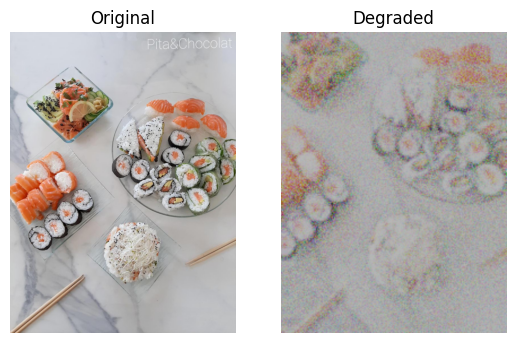

In [28]:
img_degraded = degrade("images/shushi.jpg", "images/sushi_degraded.jpg")

## 8. Turning our FoodVision Mini Gradio Demo into a deployable app

We've seen our FoodVision Mini model come to life through a Gradio demo.

But what if we wanted to share it with our friends?

Well, we could use the provided Gradio link, however, the shared link only lasts for 72-hours.

To make our FoodVision Mini demo more permanent, we can package it into an app and upload it to [Hugging Face Spaces](https://huggingface.co/spaces/launch).

### 8.1 What is Hugging Face Spaces?

Hugging Face Spaces is a resource that allows you to host and share machine learning apps.

Building a demo is one of the best ways to showcase and test what you've done.

And Spaces allows you to do just that.

You can think of Hugging Face as the GitHub of machine learning.

If having a good GitHub portfolio showcases your coding abilities, having a good Hugging Face portfolio can showcase your machine learning abilities.

> **Note:** There are many other places we could upload and host our Gradio app such as, Google Cloud, AWS (Amazon Web Services) or other cloud vendors, however, we're going to use Hugging Face Spaces due to the ease of use and wide adoption by the machine learning community.

### 8.2 Deployed Gradio app structure

To upload our demo Gradio app, we'll want to put everything relating to it into a single directory.

For example, our demo might live at the path `demos/foodvision_mini/` with the file structure:

```
demos/
└── foodvision_mini/
    ├── 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
    ├── app.py
    ├── examples/
    │   ├── example_1.jpg
    │   ├── example_2.jpg
    │   └── example_3.jpg
    ├── model.py
    └── requirements.txt
```

Where:
* `09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth` is our trained PyTorch model file.
* `app.py` contains our Gradio app (similar to the code that launched the app).
    * **Note:** `app.py` is the default filename used for Hugging Face Spaces, if you deploy your app there, Spaces will by default look for a file called `app.py` to run. This is changeable in settings.
* `examples/` contains example images to use with our Gradio app.
* `model.py` contains the model definition as well as any transforms associated with the model.
* `requirements.txt` contains the dependencies to run our app such as `torch`, `torchvision` and `gradio`.

Why this way?

Because it's one of the simplest layouts we could begin with. 

Our focus is: *experiment, experiment, experiment!* 

The quicker we can run smaller experiments, the better our bigger ones will be.

We're going to work towards recreating the structure above but you can see a live demo app running on Hugging Face Spaces as well as the file structure:
* [Live Gradio demo of FoodVision Mini 🍕🥩🍣](https://huggingface.co/spaces/mrdbourke/foodvision_mini).
* [FoodVision Mini file structure on Hugging Face Spaces](https://huggingface.co/spaces/mrdbourke/foodvision_mini/tree/main).

### 8.3 Creating a `demos` folder to store our FoodVision Mini app files

To begin, let's first create a `demos/` directory to store all of our FoodVision Mini app files.

We can do with Python's [`pathlib.Path("path_to_dir")`](https://docs.python.org/3/library/pathlib.html#basic-use) to establish the directory path and [`pathlib.Path("path_to_dir").mkdir()`](https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir) to create it. 

In [38]:
from pathlib import Path
import shutil

# 
foodvision_mini_path = Path("demos/foodvision_mini")
if foodvision_mini_path.exists():
    shutil.rmtree(foodvision_mini_path)
foodvision_mini_path.mkdir(exist_ok=True, parents=True)
!ls demos/foodvision_mini/

### 8.4 Creating a folder of example images to use with our FoodVision Mini demo

Now we've got a directory to store our FoodVision Mini demo files, let's add some examples to it.

Three example images from the test dataset should be enough.

To do so we'll:
1. Create an `examples/` directory within the `demos/foodvision_mini` directory.
2. Choose three random images from the test dataset and collect their filepaths in a list.
3. Copy the three random images from the test dataset to the `demos/foodvision_mini/examples/` directory.

In [39]:
foodvision_mini_example_path = foodvision_mini_path / "examples"
foodvision_mini_example_path.mkdir(exist_ok=True, parents=True)

list_examples = [Path(filepath) for filepath in random.sample(test_data_paths, k=3)]

for example in list_examples:
    print(f"Copying {example} to {foodvision_mini_example_path / example.name}")
    shutil.copy2(src=example, dst=foodvision_mini_example_path / example.name)

Copying data/pizza_steak_sushi_20_percent/test/pizza/833711.jpg to demos/foodvision_mini/examples/833711.jpg
Copying data/pizza_steak_sushi_20_percent/test/sushi/2903621.jpg to demos/foodvision_mini/examples/2903621.jpg
Copying data/pizza_steak_sushi_20_percent/test/sushi/389730.jpg to demos/foodvision_mini/examples/389730.jpg


Now to verify our examples are present, let's list the contents of our `demos/foodvision_mini/examples/` directory with [`os.listdir()`](https://docs.python.org/3/library/os.html#os.listdir) and then format the filepaths into a list of lists (so it's compatible with Gradio's [`gradio.Interface()`](https://gradio.app/docs/#interface) `example` parameter).

In [41]:
example_list = [["examples/"+ example] for example in os.listdir(foodvision_mini_example_path)]
example_list

[['examples/833711.jpg'], ['examples/389730.jpg'], ['examples/2903621.jpg']]

### 8.5 Moving our trained VITB16 model to our FoodVision Mini demo directory

We previously saved our FoodVision Mini VITB16 feature extractor model under `models/08_pytorch_vit_b_16_swag.pth`.

And rather double up on saved model files, let's move our model to our `demos/foodvision_mini` directory.

We can do so using Python's [`shutil.move()`](https://docs.python.org/3/library/shutil.html#shutil.move) method and passing in `src` (the source path of the target file) and `dst` (the destination path of the target file to be moved to) parameters. 

In [ ]:
src = "models/08_pytorch_vit_b_16_swag.pth"
dst = foodvision_mini_path / src.split("/")[-1]

shutil.move(src=src, dst=dst)

PosixPath('demos/foodvision_mini/08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth')

### 8.6 Turning our VITB16 model into a Python script (`model.py`)

Our current model's `state_dict` is saved to `demos/foodvision_mini/08_pytorch_vit_b_16_swag.pth`.

To load it in we can use `model.load_state_dict()` along with `torch.load()`.

> **Note:** For a refresh on saving and loading a model (or a model's `state_dict` in PyTorch, see [01. PyTorch Workflow Fundamentals section 5: Saving and loading a PyTorch model](https://www.learnpytorch.io/01_pytorch_workflow/#5-saving-and-loading-a-pytorch-model) or see the PyTorch recipe for [What is a `state_dict` in PyTorch?](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html)

But before we can do this, we first need a way to instantiate a `model`.

To do this in a modular fashion we'll create a script called `model.py` which contains our `create_vitb16_model()` function we created in [section 3.1: *Creating a function to make an VITB16 feature extractor*](https://www.learnpytorch.io/09_pytorch_model_deployment/#31-creating-a-function-to-make-an-effnetb2-feature-extractor).

That way we can import the function in *another* script (see `app.py` below) and then use it to create our VITB16 `model` instance as well as get its appropriate transforms.

Just like in [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/), we'll use the `%%writefile path/to/file` magic command to turn a cell of code into a file.

In [46]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision
from torch import nn

def create_vitb16_model(num_classes: int = 3,
                        seed: int = 42) -> Tuple [nn.Module, torchvision.transforms.Compose]:
    """
    Create a ViT-B/16 feature extractor model and transforms

    Args:
        num_classes (int, optional): number of classes. Defaults to 3.
        seed (int, optional): random seed. Defaults to 42.

    Returns:
        model (nn.Module): ViT-B/16 feature extractor model, 
        transforms (torchvision.transforms.Compose): ViT-B/16 images transforms
    """
    # Get the model weights
    weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
    # Get automatic transforms from pretrained ViT weights
    transforms = weights.transforms()
    # Get the model architecture with pretrained weights
    model = torchvision.models.vit_b_16(weights=weights)
    # Get the last layer input
    for module in reversed(list(pretrained_vit_swag.modules())):
        if isinstance(module, nn.Linear):
            in_features = module.in_features     
    # Get its head
    torch.manual_seed(seed)
    model.heads = nn.Linear(in_features=in_features, out_features=num_classes)
    return model, transforms

Writing demos/foodvision_mini/model.py


### 8.7 Turning our FoodVision Mini Gradio app into a Python script (`app.py`)

We've now got a `model.py` script as well as a path to a saved model `state_dict` that we can load in.

Time to construct `app.py`.

We call it `app.py` because by default when you create a HuggingFace Space, it looks for a file called `app.py` to run and host (though you can change this in settings).

Our `app.py` script will put together all of the pieces of the puzzle to create our Gradio demo and will have four main parts: 

1. **Imports and class names setup** - Here we'll import the various dependencies for our demo including the `create_vitb16_model()` function from `model.py` as well as setup the different class names for our FoodVision Mini app. 
2. **Model and transforms preparation** - Here we'll create a VitB16 model instance along with the transforms to go with it and then we'll load in the saved model weights/`state_dict`. When we load the model we'll also set `map_location=torch.device("cpu")` in [`torch.load()`](https://pytorch.org/docs/stable/generated/torch.load.html) so our model gets loaded onto the CPU regardless of the device it trained on (we do this because we won't necessarily have a GPU when we deploy and we'll get an error if our model is trained on GPU but we try to deploy it to CPU without explicitly saying so).
3. **Predict function** - Gradio's `gradio.Interface()` takes a `fn` parameter to map inputs to outputs, our `predict()` function will be the same as the one we defined above in [section 7.2: *Creating a function to map our inputs and outputs*](https://www.learnpytorch.io/09_pytorch_model_deployment/#72-creating-a-function-to-map-our-inputs-and-outputs), it will take in an image and then use the loaded transforms to preprocess it before using the loaded model to make a prediction on it.
    * **Note:** We'll have to create the example list on the fly via the `examples` parameter. We can do so by creating a list of the files inside the `examples/` directory with: `[["examples/" + example] for example in os.listdir("examples")]`.
4. **Gradio app** - This is where the main logic of our demo will live, we'll create a `gradio.Interface()` instance called `demo` to put together our inputs, `predict()` function and outputs. And we'll finish the script by calling `demo.launch()` to launch our FoodVision Mini demo!

In [ ]:
%%writefile demos/foodvision_mini/app.py
### 1. Imports and class names setup ### 
import gradio as gr
import os
import torch

from model import create_vitb16_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ["pizza", "steak", "sushi"]

### 2. Model and transforms preparation ###

# Create the ViTB16 model
vitb16, vitb16_transforms = create_vitb16_model(
    num_classes=3, # len(class_names) would also work
)

# Load saved weights
vitb16.load_state_dict(
    torch.load(
        f="08_pytorch_vit_b_16_swag.pth",
        map_location=torch.device("cpu"),  # load to CPU
    )
)

### 3. Predict function ###

# Create predict function
def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = vitb16_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    vitb16.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(vitb16(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

### 4. Gradio app ###

# Create title, description and article strings
title = "FoodVision Mini 🍕🥩🍣"
description = "A VitB16 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"), # what are the inputs?
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # what are the outputs?
                             gr.Number(label="Prediction time (s)")], # our fn has two outputs, therefore we have two outputs
                    # Create examples list from "examples/" directory
                    examples=example_list, 
                    title=title,
                    description=description,
                    article=article)

# Launch the demo!
demo.launch()

Overwriting demos/foodvision_mini/app.py


In [53]:
%%writefile demos/foodvision_mini/requirements.txt
torch==2.9.1
torchvision==0.24.1
gradio==6.0.2

Writing demos/foodvision_mini/requirements.txt


## 9. Deploying our FoodVision Mini app to HuggingFace Spaces

We've got a file containing our FoodVision Mini demo, now how do we get it to run on Hugging Face Spaces?

There are two main options for uploading to a Hugging Face Space (also called a [Hugging Face Repository](https://huggingface.co/docs/hub/repositories-getting-started#getting-started-with-repositories), similar to a git repository): 
1. [Uploading via the Hugging Face Web interface (easiest)](https://huggingface.co/docs/hub/repositories-getting-started#adding-files-to-a-repository-web-ui).
2. [Uploading via the command line or terminal](https://huggingface.co/docs/hub/repositories-getting-started#terminal).
    * **Bonus:** You can also use the [`huggingface_hub` library](https://huggingface.co/docs/huggingface_hub/index) to interact with Hugging Face, this would be a good extension to the above two options.

Feel free to read the documentation on both options but we're going to go with option two.

> **Note:** To host anything on Hugging Face, you will need to [sign up for a free Hugging Face account](https://huggingface.co/join). 

### 9.1 Downloading our FoodVision Mini app files

Let's check out the demo files we've got inside `demos/foodvision_mini`.

To do so we can use the `!ls` command followed by the target filepath.

`ls` stands for "list" and the `!` means we want to execute the command at the shell level.

In [55]:
!ls demos/foodvision_mini

08_pretrained_vit_feature_extractor_pizza_steak_sushi.pth  model.py
app.py							   requirements.txt
examples


### 9.2 Running our FoodVision Mini demo locally

If you download the `foodvision_mini.zip` file, you can test it locally by:
1. Unzipping the file.
2. Opening terminal or a command line prompt.
3. Changing into the `foodvision_mini` directory (`cd foodvision_mini`).
4. Creating an environment (`python3 -m venv env`).
5. Activating the environment (`source env/bin/activate`).
5. Installing the requirements (`pip install -r requirements.txt`, the "`-r`" is for recursive).
    * **Note:** This step may take 5-10 minutes depending on your internet connection. And if you're facing errors, you may need to upgrade `pip` first: `pip install --upgrade pip`.
6. Run the app (`python3 app.py`).

This should result in a Gradio demo just like the one we built above running locally on your machine at a URL such as `http://127.0.0.1:7860/`.

> **Note:** If you run the app locally and you notice a `flagged/` directory appear, it contains samples that have been "flagged". 
>
> For example, if someone tries the demo and the model produces an incorrect result, the sample can be "flagged" and reviewed for later.
> 
> For more on flagging in Gradio, see the [flagging documentation](https://gradio.app/docs/#flagging).

### 9.3 Uploading to Hugging Face

We've verified our FoodVision Mini app works locally, however, the fun of creating a machine learning demo is to show it to other people and allow them to use it.

To do so, we're going to upload our FoodVision Mini demo to Hugging Face. 

> **Note:** The following series of steps uses a Git (a file tracking system) workflow. For more on how Git works, I'd recommend going through the [Git and GitHub for Beginners tutorial](https://youtu.be/RGOj5yH7evk) on freeCodeCamp.

1. [Sign up](https://huggingface.co/join) for a Hugging Face account. 
2. Start a new Hugging Face Space by going to your profile and then [clicking "New Space"](https://huggingface.co/new-space).
    * **Note:** A Space in Hugging Face is also known as a "code repository" (a place to store your code/files) or "repo" for short.
3. Give the Space a name, for example, mine is called `mrdbourke/foodvision_mini`, you can see it here: https://huggingface.co/spaces/mrdbourke/foodvision_mini
4. Select a license (I used [MIT](https://opensource.org/licenses/MIT)).
5. Select Gradio as the Space SDK (software development kit). 
   * **Note:** You can use other options such as Streamlit but since our app is built with Gradio, we'll stick with that.
6. Choose whether your Space is it's public or private (I selected public since I'd like my Space to be available to others).
7. Click "Create Space".
8. Clone the repo locally by running something like: `git clone https://huggingface.co/spaces/[YOUR_USERNAME]/[YOUR_SPACE_NAME]` in terminal or command prompt.
    * **Note:** You can also add files via uploading them under the "Files and versions" tab.
9. Copy/move the contents of the downloaded `foodvision_mini` folder to the cloned repo folder.
10. To upload and track larger files (e.g. files over 10MB or in our case, our PyTorch model file) you'll need to [install Git LFS](https://git-lfs.github.com/) (which stands for "git large file storage").
11. After you've installed Git LFS, you can activate it by running `git lfs install`.
12. In the `foodvision_mini` directory, track the files over 10MB with Git LFS with `git lfs track "*.file_extension"`.
    * Track VitB16 PyTorch model file with `git lfs track "08_pytorch_vit_b_16_swag.pth"`.
13. Track `.gitattributes` (automatically created when cloning from HuggingFace, this file will help ensure our larger files are tracked with Git LFS). You can see an example `.gitattributes` file on the [FoodVision Mini Hugging Face Space](https://huggingface.co/spaces/mrdbourke/foodvision_mini/blob/main/.gitattributes).
    * `git add .gitattributes`
14. Add the rest of the `foodvision_mini` app files and commit them with: 
    * `git add *`
    * `git commit -m "first commit"`
15. Push (upload) the files to Hugging Face:
    * `git push`
16. Wait 3-5 minutes for the build to happen (future builds are faster) and your app to become live!

If everything worked, you should see a live running example of our FoodVision Mini Gradio demo like the one here: https://huggingface.co/spaces/mrdbourke/foodvision_mini 

And we can even embed our FoodVision Mini Gradio demo into our notebook as an [iframe](https://gradio.app/sharing_your_app/#embedding-with-iframes) with [`IPython.display.IFrame`](https://ipython.readthedocs.io/en/stable/api/generated/IPython.display.html#IPython.display.IFrame) and a link to our space in the format `https://hf.space/embed/[YOUR_USERNAME]/[YOUR_SPACE_NAME]/+`.